In [ ]:
from google.colab import files
uploaded = files.upload()  
!unzip testing_asim.zip -d /content/CV-BeeOrientation
%cd /content/CV-BeeOrientation


In [ ]:

%cd /content/CV-BeeOrientation
!pip install -r requirements.txt


In [3]:
%cd /content/CV-BeeOrientation
!ls
import sys
sys.path.append("/content/CV-BeeOrientation/src")


/content/CV-BeeOrientation
data	 notebooks  requirements.txt  src
LICENSE  README.md  scripts	      testing.ipynb


In [ ]:
# 2) Imports und Device-Setup
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from dataset     import BeeSegmentationDataset
from models.base import UNet3  



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on", device)


Running on cuda


In [ ]:
# 3) Dataset & DataLoaders
IMG_DIR = "data/processed/images"
MSK_DIR = "data/processed/masks"


full_ds = BeeSegmentationDataset(IMG_DIR, MSK_DIR)

# split 80/20
n_val = int(len(full_ds) * 0.2)
n_tr  = len(full_ds) - n_val
train_ds, val_ds = random_split(full_ds, [n_tr, n_val],
                                generator=torch.Generator().manual_seed(42))

# DataLoader
batch_size = 8
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")


Train samples: 277, Val samples: 69


In [ ]:
# 4) Model, Loss, Optimizer, Scheduler
model = UNet3(in_channels=1, num_classes=1).to(device)

criterion = nn.BCEWithLogitsLoss()  
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)


In [14]:

num_epochs = 20
best_val_loss = float('inf')

for epoch in range(1, num_epochs+1):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device, dtype=torch.float32).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device, dtype=torch.float32).unsqueeze(1)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * imgs.size(0)
    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:02d}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    # --- Checkpoint speichern ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "unet_best.pth")
        print(f"  → Neues Bestmodell mit Val Loss {best_val_loss:.4f} gespeichert")


Epoch 01: Train Loss = 0.6245, Val Loss = 0.5563
  → Neues Bestmodell mit Val Loss 0.5563 gespeichert
Epoch 02: Train Loss = 0.4579, Val Loss = 0.4313
  → Neues Bestmodell mit Val Loss 0.4313 gespeichert
Epoch 03: Train Loss = 0.4085, Val Loss = 0.3719
  → Neues Bestmodell mit Val Loss 0.3719 gespeichert
Epoch 04: Train Loss = 0.3530, Val Loss = 0.2869
  → Neues Bestmodell mit Val Loss 0.2869 gespeichert
Epoch 05: Train Loss = 0.2910, Val Loss = 0.3188
Epoch 06: Train Loss = 0.3165, Val Loss = 0.2840
  → Neues Bestmodell mit Val Loss 0.2840 gespeichert
Epoch 07: Train Loss = 0.2708, Val Loss = 0.2580
  → Neues Bestmodell mit Val Loss 0.2580 gespeichert
Epoch 08: Train Loss = 0.2475, Val Loss = 0.2376
  → Neues Bestmodell mit Val Loss 0.2376 gespeichert
Epoch 09: Train Loss = 0.2394, Val Loss = 0.2362
  → Neues Bestmodell mit Val Loss 0.2362 gespeichert
Epoch 10: Train Loss = 0.2340, Val Loss = 0.2291
  → Neues Bestmodell mit Val Loss 0.2291 gespeichert
Epoch 11: Train Loss = 0.2275, Va

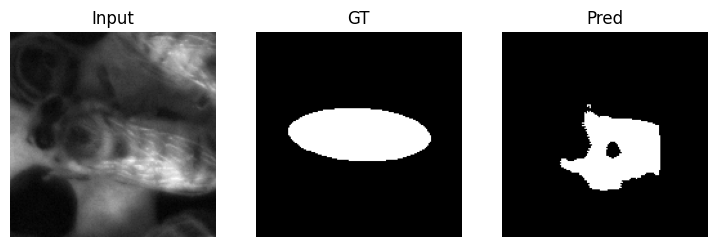

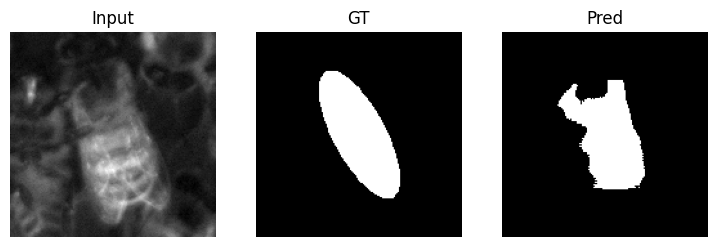

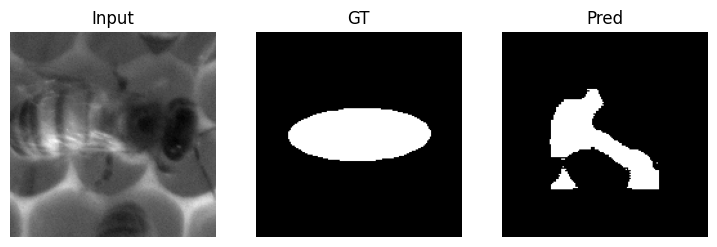

In [15]:
imgs, masks = next(iter(val_loader))
with torch.no_grad():
    preds = (torch.sigmoid(model(imgs.to(device))) > 0.5).cpu()


for i in range(3):
    fig, axs = plt.subplots(1,3, figsize=(9,3))
    axs[0].imshow(imgs[i,0], cmap='gray');     axs[0].set_title("Input");
    axs[1].imshow(masks[i],   cmap='gray');    axs[1].set_title("GT");
    axs[2].imshow(preds[i,0],cmap='gray');    axs[2].set_title("Pred");
    for ax in axs: ax.axis('off')
    plt.show()
